# 06 Business Insights & Aggregations
**Project:** Retailmart Finance Analytics  
**Phase:** Analyze trends and extract actionable insights for decision-makers.

---

### 1. Setup & Imports
We must add the parent directory to the system path so Python can locate the custom `src` modules.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# Add root directory to python path
sys.path.append(os.path.abspath(os.path.join('..')))

# Import custom configurations and utilities
from src.config.config import config
from src.database.connection import db_connector
from src.utils.logger import setup_logger
from src.utils.helpers import save_dataframe

logger = setup_logger(os.path.splitext(os.path.basename('__file__'))[0])
logger.info('Notebook setup and imports loaded successfully.')

[2026-07-19 16:20:02] [INFO] [config.py:16] Loaded environment configuration from: E:\SQL ACCIO JOB\Cross functional dashboard\.env
[2026-07-19 16:20:03] [INFO] [connection.py:42] SQLAlchemy Database Engine initialized successfully.
[2026-07-19 16:20:03] [INFO] [4206973462.py:16] Notebook setup and imports loaded successfully.


### 2. Top Performing Regions/Stores
Placeholder for top performing regions/stores steps.

In [2]:
# --- Python equivalent of Phase 6 Challenge 1 ---
import os

# 1. Load the required tables
processed_dir = "../data/processed"
orders_df = pd.read_csv(os.path.join(processed_dir, "sales_transaction_orders.csv"))
dealers_df = pd.read_csv(os.path.join(processed_dir, "dealer_dealers.csv"))
cities_df = pd.read_csv(os.path.join(processed_dir, "location_reference_cities.csv"))
states_df = pd.read_csv(os.path.join(processed_dir, "location_reference_states.csv"))

# 2. Multi-join (Merge)
merged = pd.merge(orders_df, dealers_df, on="dealer_id")
merged = pd.merge(merged, cities_df, on="city_id")
merged = pd.merge(merged, states_df, on="state_id")

# 3. Group by region and aggregate
region_summary = merged.groupby("region")["net_amount"].agg(
    total_orders="count",
    total_revenue="sum"
).reset_index()

# 4. Sort and format numbers for display
region_summary = region_summary.sort_values(by="total_revenue", ascending=False)
region_summary["total_revenue"] = region_summary["total_revenue"].map(lambda x: f"${x:,.2f}")

# 5. Display the regional leaderboard
print("--- Regional Sales Leaderboard ---")
print(region_summary.to_string(index=False))

--- Regional Sales Leaderboard ---
 region  total_orders     total_revenue
  North          2559 $4,588,060,997.55
   East          1693 $3,004,346,311.40
   West          1011 $1,864,069,920.05
  South          1026 $1,797,106,999.65
Central           711 $1,280,763,616.84


C:\Users\ishup\AppData\Local\Temp\ipykernel_4848\2984618028.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


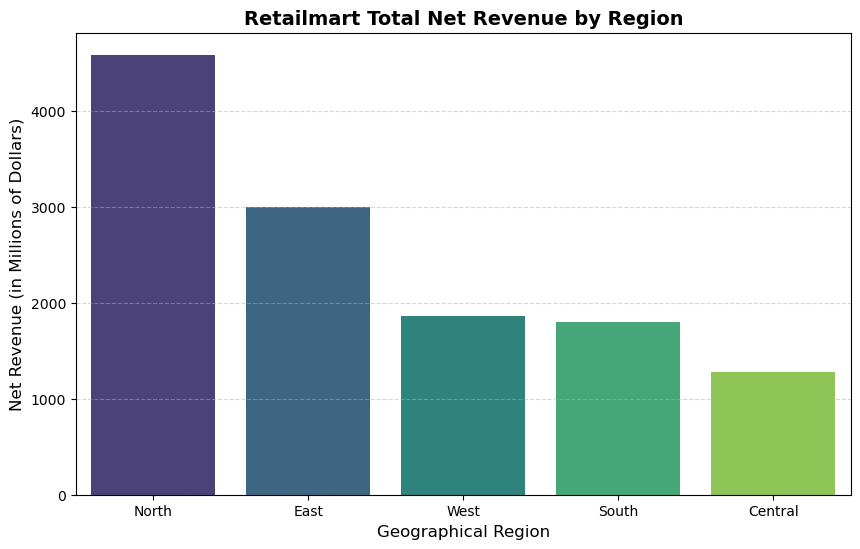

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recalculate raw numeric sums for plotting (without formatting as text)
region_numeric = merged.groupby("region")["net_amount"].sum().reset_index()
region_numeric = region_numeric.sort_values(by="net_amount", ascending=False)

# 2. Set the canvas size
plt.figure(figsize=(10, 6))

# 3. Draw a vertical bar chart
# We divide by 1,000,000 to show the Y-axis in "Millions of Dollars" (makes labels cleaner)
region_numeric["revenue_millions"] = region_numeric["net_amount"] / 1000000.0

sns.barplot(
    data=region_numeric, 
    x="region", 
    y="revenue_millions", 
    palette="viridis" # A modern, vibrant color palette
)

# 4. Add labels, grid lines, and titles
plt.title("Retailmart Total Net Revenue by Region", fontsize=14, fontweight="bold")
plt.xlabel("Geographical Region", fontsize=12)
plt.ylabel("Net Revenue (in Millions of Dollars)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# 5. Display the plot
plt.show()

### 3. Seasonal Revenue Performance
Placeholder for seasonal revenue performance steps.

--- Top 10 Showrooms Leaderboard ---
               dealer_name     state_name  total_orders  total_revenue
       Dada Motors Dhanbad Andhra Pradesh            47 $94,050,873.16
     Kar Motors Chandrapur            Goa            50 $92,021,301.79
     Ahuja Motors Suryapet        Mizoram            45 $89,153,735.34
   Chaudhry Motors Bikaner         Sikkim            49 $86,400,299.95
      Nagi Motors Durgapur    Uttarakhand            48 $85,810,655.72
   Sankar Motors Allahabad  Uttar Pradesh            44 $84,296,094.21
       Sarraf Motors Jalna         Punjab            44 $83,425,868.53
    Sunder Motors Guwahati          Assam            45 $82,869,317.21
     Kakar Motors Bhiwandi    Maharashtra            43 $80,911,159.02
Dixit Motors Vijayanagaram Madhya Pradesh            44 $80,368,668.28




C:\Users\ishup\AppData\Local\Temp\ipykernel_4848\3039894809.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


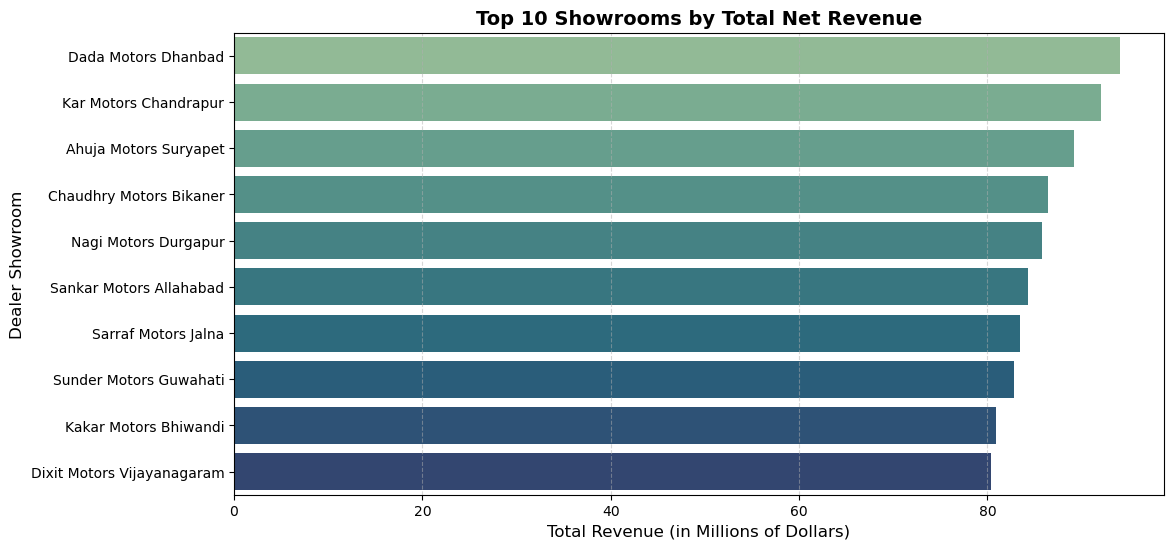

In [4]:
# --- Python equivalent of Phase 6 Challenge 2 (with Horizontal Bar Chart) ---

# 1. Group, aggregate, and grab top 10
showroom_leaderboard = merged.groupby(["dealer_name", "state_name"])["net_amount"].agg(
    total_orders="count",
    total_revenue="sum"
).reset_index()

top_10_showrooms = showroom_leaderboard.sort_values(by="total_revenue", ascending=False).head(10)

# Create a clean display version with mapping (for text output)
display_table = top_10_showrooms.copy()
display_table["total_revenue"] = display_table["total_revenue"].map(lambda x: f"${x:,.2f}")
print("--- Top 10 Showrooms Leaderboard ---")
print(display_table.to_string(index=False))
print("\n")

# 2. Draw the Horizontal Bar Chart
plt.figure(figsize=(12, 6))

# Calculate revenue in millions for clean chart labels
top_10_showrooms["revenue_millions"] = top_10_showrooms["total_revenue"] / 1000000.0

sns.barplot(
    data=top_10_showrooms, 
    x="revenue_millions", 
    y="dealer_name", # Putting names on Y-axis makes it horizontal!
    palette="crest"
)

# 3. Format titles and grid lines
plt.title("Top 10 Showrooms by Total Net Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue (in Millions of Dollars)", fontsize=12)
plt.ylabel("Dealer Showroom", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)

# 4. Display the chart
plt.show()

### 4. Customer segment profitability
Placeholder for customer segment profitability steps.

### 5. Actionable Business Recommendations
Placeholder for actionable business recommendations steps.